In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

df = pd.read_csv('Online_Retail.csv', encoding='latin1')
print(df.shape)
df.head()

(541909, 8)


,ï»¿InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [2]:
# Remove missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove negative quantities (returns)
df = df[df['Quantity'] > 0]

# Remove zero price items
df = df[df['UnitPrice'] > 0]

print("Clean data shape:", df.shape)

Clean data shape: (397884, 8)


In [3]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df.head()

,ï»¿InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom,20.34


In [4]:
# Save data into a SQLite database
conn = sqlite3.connect('retail.db')
df.to_sql('transactions', conn, if_exists='replace', index=False)
print("Data saved to SQL database!")

Data saved to SQL database!


In [6]:
# Query 1 - Top 10 countries by revenue
query1 = pd.read_sql("""
    SELECT Country, 
           ROUND(SUM(Quantity * UnitPrice), 2) as Revenue
    FROM transactions
    GROUP BY Country
    ORDER BY Revenue DESC
    LIMIT 10
""", conn)
print(query1)

          Country     Revenue
0  United Kingdom  7308391.55
1     Netherlands   285446.34
2            EIRE   265545.90
3         Germany   228867.14
4          France   209024.05
5       Australia   138521.31
6           Spain    61577.11
7     Switzerland    56443.95
8         Belgium    41196.34
9          Sweden    38378.33


In [7]:
# Query 2 - Monthly revenue trend
query2 = pd.read_sql("""
    SELECT SUBSTR(InvoiceDate, 1, 7) as Month,
           ROUND(SUM(Quantity * UnitPrice), 2) as Revenue
    FROM transactions
    GROUP BY Month
    ORDER BY Month
""", conn)
print(query2)

       Month   Revenue
0    01-02-2  26376.50
1    01-03-2  23631.87
2    01-04-2  24586.82
3    01-05-2   6973.66
4    01-06-2  15390.89
..       ...       ...
293  31-03-2  25688.61
294  31-05-2  18194.65
295  31-07-2  33393.29
296  31-08-2  20540.84
297  31-10-2  33048.57

[298 rows x 2 columns]


In [9]:
pd.read_sql("PRAGMA table_info(transactions);", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,ï»¿InvoiceNo,TEXT,0,None,0
1,1,StockCode,TEXT,0,None,0
2,2,Description,TEXT,0,None,0
3,3,Quantity,INTEGER,0,None,0
4,4,InvoiceDate,TEXT,0,None,0
5,5,UnitPrice,REAL,0,None,0
6,6,CustomerID,REAL,0,None,0
7,7,Country,TEXT,0,None,0
8,8,TotalPrice,REAL,0,None,0


In [11]:
df.columns = df.columns.str.replace('\ufeff', '')

In [12]:
conn = sqlite3.connect('retail.db')
df.to_sql('transactions', conn, if_exists='replace', index=False)



397884

In [13]:
pd.read_sql("PRAGMA table_info(transactions);", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,ï»¿InvoiceNo,TEXT,0,None,0
1,1,StockCode,TEXT,0,None,0
2,2,Description,TEXT,0,None,0
3,3,Quantity,INTEGER,0,None,0
4,4,InvoiceDate,TEXT,0,None,0
5,5,UnitPrice,REAL,0,None,0
6,6,CustomerID,REAL,0,None,0
7,7,Country,TEXT,0,None,0
8,8,TotalPrice,REAL,0,None,0


In [14]:
df.columns = df.columns.str.replace('\ufeff', '')

In [15]:
print(df.columns)


Index(['ï»¿InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalPrice'],
      dtype='object')


In [16]:
df.columns = df.columns.str.replace('ï»¿', '')

In [17]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalPrice'],
      dtype='object')


In [18]:
conn = sqlite3.connect('retail.db')
df.to_sql('transactions', conn, if_exists='replace', index=False)

397884

In [20]:
# Query 3 - Customer total spending
query3 = pd.read_sql("""
    SELECT CustomerID,
           COUNT(DISTINCT InvoiceNo) as Frequency,
           ROUND(SUM(Quantity * UnitPrice), 2) as Total_Spending
    FROM transactions
    GROUP BY CustomerID
    ORDER BY Total_Spending DESC
""", conn)
print(query3.head())

   CustomerID  Frequency  Total_Spending
0     14646.0         73       280206.02
1     18102.0         60       259657.30
2     17450.0         46       194550.79
3     16446.0          2       168472.50
4     14911.0        201       143825.06


In [21]:
customer_df = query3.copy()
customer_df['Avg_Order_Value'] = customer_df['Total_Spending'] / customer_df['Frequency']

def segment(x):
    if x > 10000:
        return "High Value"
    elif x > 5000:
        return "Medium Value"
    else:
        return "Low Value"

customer_df['Segment'] = customer_df['Total_Spending'].apply(segment)
customer_df.head()

,CustomerID,Frequency,Total_Spending,Avg_Order_Value,Segment
0,14646.0,73,280206.02,3838.438630,High Value
1,18102.0,60,259657.30,4327.621667,High Value
2,17450.0,46,194550.79,4229.365000,High Value
3,16446.0,2,168472.50,84236.250000,High Value
4,14911.0,201,143825.06,715.547562,High Value


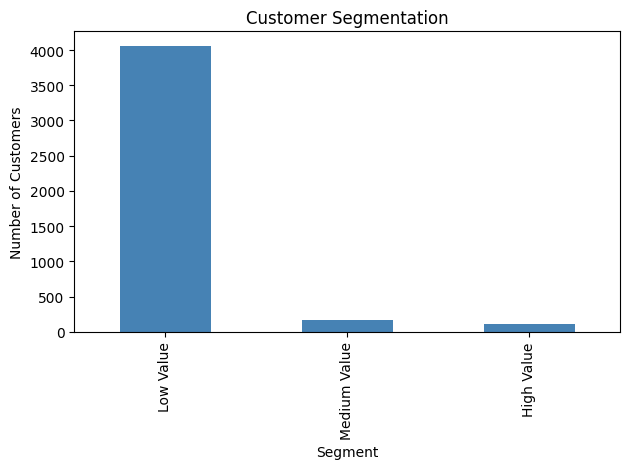

In [22]:
# Chart 1 - Segment count
customer_df['Segment'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Customer Segmentation')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('chart_segments.png')  # saves image for GitHub
plt.show()

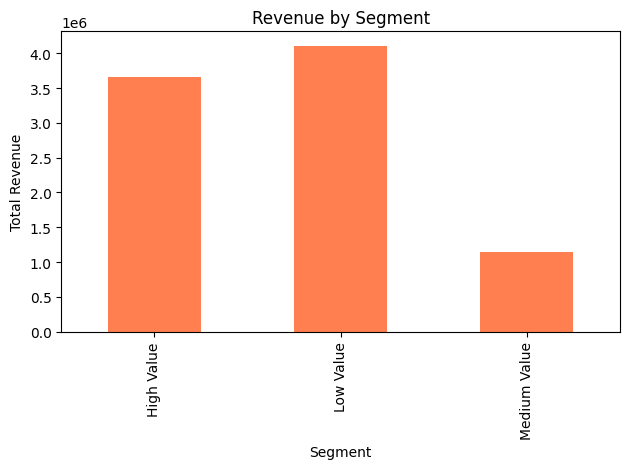

In [23]:
# Chart 2 - Revenue by segment
customer_df.groupby('Segment')['Total_Spending'].sum().plot(kind='bar', color='coral')
plt.title('Revenue by Segment')
plt.xlabel('Segment')
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.savefig('chart_revenue.png')
plt.show()

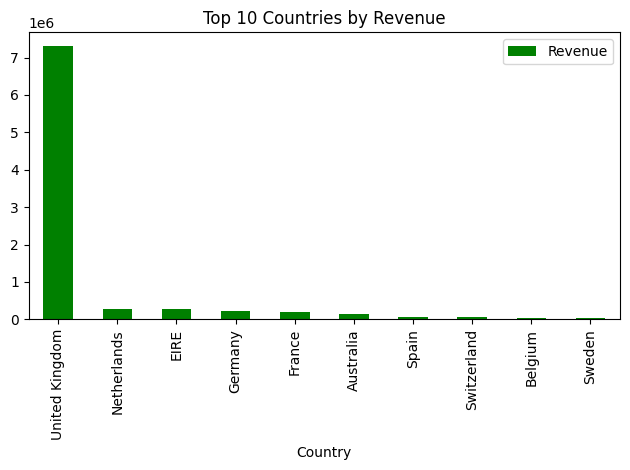

In [25]:
# Chart 3 - Top 10 countries
query1.plot(kind='bar', x='Country', y='Revenue', color='green')
plt.title('Top 10 Countries by Revenue')
plt.tight_layout()
plt.savefig('chart_countries.png')
plt.show()

In [28]:
with pd.ExcelWriter('segmentation_report.xlsx', engine='openpyxl') as writer:
    customer_df.to_excel(writer, sheet_name='Customer Segments', index=False)
    query1.to_excel(writer, sheet_name='Revenue by Country', index=False)
    query2.to_excel(writer, sheet_name='Monthly Revenue', index=False)

print("Excel report saved!")

Excel report saved!
